# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
print(miss)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = [c for c in["class", "who", "adult_male", "deck", "embark_town", "alive", "alone"] if c in df.columns]# điền danh sách cột cần bỏ (chỉ những cột có trong df)
print("Các cột rò rỉ/dư thừa:", leaky)
df = df.drop(columns = leaky)
print("Các cột còn lại:", list(df.columns))

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64
Các cột rò rỉ/dư thừa: ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive`(no/yes) chỉ là `cách viết chữ khác` của `survived`(0/1), nếu để `alive` làm feature:
- Mô hình sẽ học quy tắc "nếu alive=yes thì survived=1" và ngược lại - một phép ánh xạ, mô hình sẽ kh học được quy luật gì từ các mối quan hệ sex/age/embarked
- Accuracy ~ 100% trên tập test/train hiện tại, nhưng lại vô dụng trên thực tế

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
# 1. shape(dòng, cột) dòng-hành khách, cột-features
print("Biến mục tiêu: 'Survived' |", df.shape[0], "mẫu,", df.shape[1], "cột")

# 2. xem kiểu dữ liệu và số giá trị non-null
print(df.info())

# 3. describe() thống kê các cột số
# Biến số
print(" Thống kê biến số ")
display(df.describe())
# Biến phân loại
print("\nThống kê biến chữ ")
display(df.describe(include="object"))

Biến mục tiêu: 'Survived' | 891 mẫu, 8 cột
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None
 Thống kê biến số 


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thống kê biến chữ 


C:\Users\AD\AppData\Local\Temp\ipykernel_31260\1515093053.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**
- Biến số: `age`, `sibsp`, `parch`, `fare`, 
- Biến phân loại: <p>+ `survived`(nhị phân), `pclass`(có thứ tự - ordinal)
                  <p>+`sex`, `embarked`(danh nghĩa - nominal)

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_value_count = df.isnull().sum(axis = 0)
# Tỷ lệ % của missing value theo cột
percentage_missing_value = (df.isnull().mean(axis = 0) * 100).round(2)

# Lập bảng missing
bang_missing = pd.DataFrame({
        "Tong so missing value cua cot" : missing_value_count,
        "Ty le (%)" : percentage_missing_value
})
bang_missing = bang_missing[bang_missing["Tong so missing value cua cot"] > 0].sort_values("Ty le (%)", ascending = False)
print(bang_missing)
print("Gia tri skewness cua cot age:" , df["age"].skew().round(2))

          Tong so missing value cua cot  Ty le (%)
age                                 177      19.87
embarked                              2       0.22
Gia tri skewness cua cot age: 0.39


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

### ĐỀ XUẤT XỬ LÝ DỮ LIỆU KHUYẾT THIẾU

| Cột | % Thiếu | Phương pháp xử lý | Lý do đề xuất |
| :--- | :---: | :--- | :--- |
| **age** <br>*(Biến liên tục)* | ~19.87% | **Imputation (Median)** | Tỷ lệ khuyết chưa đến mức phải xóa cột và đây không phải biến target. Phân phối dữ liệu lệch phải (Skewness = 0.39) do có nhóm khách lớn tuổi (outliers), dùng *Median* sẽ tối ưu và bền vững hơn *Mean*. |
| **embarked** <br>*(Biến phân loại)* | ~0.22% | **Imputation (Mode)** | Là biến phân loại có tỷ lệ khuyết cực kỳ thấp. Việc điền *Mode* giúp xử lý nhanh và không làm ảnh hưởng đến phân phối chung của biến. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
# Tính theo IQR
def dem_outlier_iqr(s):
    s = s.dropna()
    s_q1 = s.quantile(0.25)
    s_q3 = s.quantile(0.75)
    
    s_iqr = s_q3 - s_q1
    can_duoi = s_q1 - 1.5 * s_iqr
    can_tren = s_q3 + 1.5 * s_iqr
    
    tong_outlier_iqr = ((s < can_duoi) | (s > can_tren)).sum()
    return tong_outlier_iqr , can_duoi, can_tren

# Tính theo z_score
def dem_outlier_zscore(s, nguong = 3.0):
    z_scores = np.abs(stats.zscore(s.dropna()))
    tong_outlier_zscore = (z_scores > nguong).sum()
    return tong_outlier_zscore

# In số outlier tính theo iqr và z_score cho hai đặc trưng
for col in ["age", "fare"]:
    iqr, low, high = dem_outlier_iqr(df[col])
    zscores = dem_outlier_zscore(df[col])
    print(f"Cot {col}:")
    print(f" - IQR : {iqr} outlier (ngoài [{low:.1f}, {high:.1f}])")
    print(f" - Z-score : {zscores} outlier (|z-score| > 3)")
    print()

Cot age:
 - IQR : 11 outlier (ngoài [-6.7, 64.8])
 - Z-score : 2 outlier (|z-score| > 3)

Cot fare:
 - IQR : 116 outlier (ngoài [-26.7, 65.6])
 - Z-score : 20 outlier (|z-score| > 3)



**Trả lời 4 (quyết định với outlier của `fare`):**
* **Quyết định:** **Giữ lại toàn bộ dữ liệu ngoại lai (outliers) của biến `fare`.**

| Đặc trưng | Hiện tượng | Nguyên nhân kỹ thuật | Hệ quả nếu xóa |
| :--- | :--- | :--- | :--- |
| **fare** | Xuất hiện các điểm giá trị cao bất thường (outliers). | Không phải lỗi nhập liệu. Đây là giá vé thực tế của nhóm hành khách Hạng Nhất (`pclass = 1`). | Sẽ làm mất đi thông tin của nhóm hành khách giàu có — nhóm có tương quan rất mạnh với tỷ lệ sống sót (do vị trí phòng ở tầng cao, gần phao cứu sinh hơn). |

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

Gia tri skewness cua cot age: 0.39
Gia tri skewness cua cot fare: 4.79



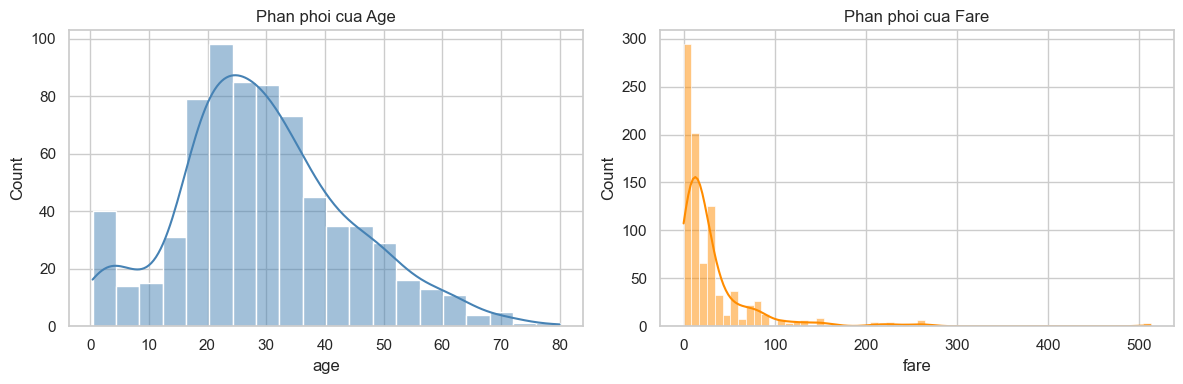

In [7]:
# TODO 5a: Histogram age & fare
print("Gia tri skewness cua cot age:" , df["age"].skew().round(2))
print("Gia tri skewness cua cot fare:" , df["fare"].skew().round(2))
print()

fig, axes = plt.subplots(1, 2, figsize = (12 , 4))
# Histogram của đặc trung age
sns.histplot(df["age"], kde = True, ax = axes[0], color = "steelblue")
axes[0].set_title("Phan phoi cua Age")
axes[0].set_xlabel("age")

# Histogram của đặc trung fare
sns.histplot(df["fare"], kde = True, ax = axes[1], color = "darkorange")
axes[1].set_title("Phan phoi cua Fare")
axes[1].set_xlabel("fare")

plt.tight_layout()
plt.show()

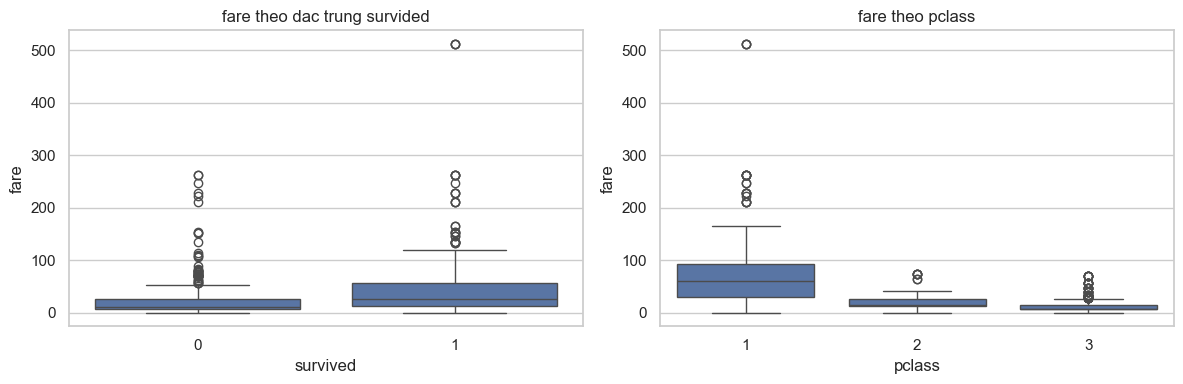

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize = (12 , 4))

sns.boxplot(data = df, x = "survived", y = "fare", ax = axes[0])
axes[0].set_title("fare theo dac trung survided")

sns.boxplot(data = df, x = "pclass", y = "fare", ax = axes[1])
axes[1].set_title("fare theo pclass")

plt.tight_layout()
plt.show()

Ty le song sot theo sex:
sex
female    0.74
male      0.19
Name: survived, dtype: float64

Ty le song sot theo pclass:
pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64


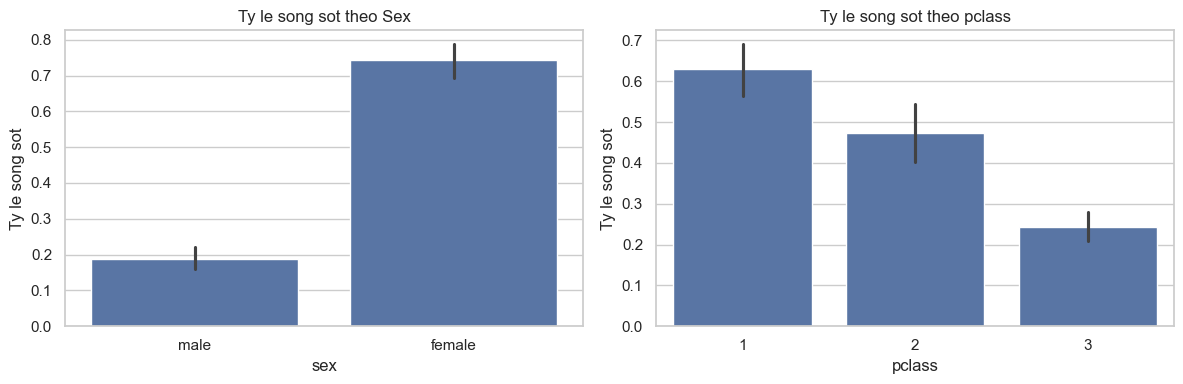

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize = (12 , 4))

print("Ty le song sot theo sex:")
print(df.groupby("sex")["survived"].mean().round(2))
print("\nTy le song sot theo pclass:")
print(df.groupby("pclass")["survived"].mean().round(2))

sns.barplot(data = df, x = "sex", y = "survived", ax = axes[0])
axes[0].set_title("Ty le song sot theo Sex")
axes[0].set_ylabel("Ty le song sot")

sns.barplot(data = df, x = "pclass", y = "survived", ax = axes[1])
axes[1].set_title("Ty le song sot theo pclass")
axes[1].set_ylabel("Ty le song sot")

plt.tight_layout()
plt.show()


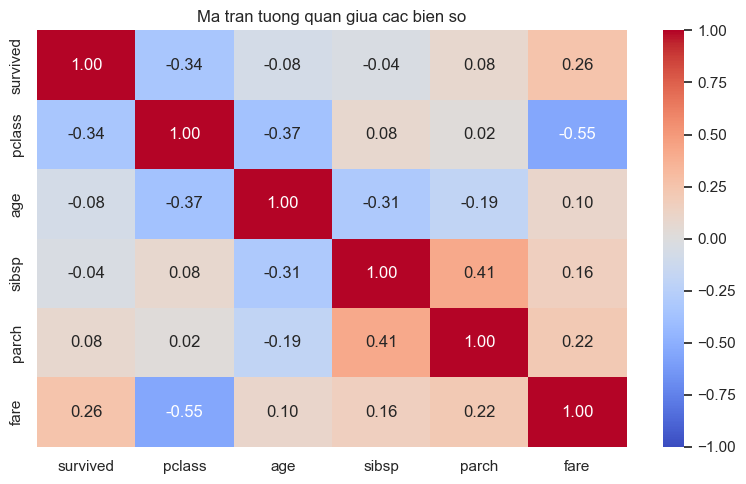

In [10]:
# TODO 5d: Heatmap correlation
ma_tran_bien_so = df.select_dtypes(include = "number")
ma_tran_tuong_duong = ma_tran_bien_so.corr()

plt.figure(figsize = (8 , 5))
sns.heatmap(ma_tran_tuong_duong, vmin = -1, vmax = 1, cmap = "coolwarm", annot = True, fmt = ".2f", center = 0)
plt.title("Ma tran tuong quan giua cac bien so")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**
#### 1. Biểu đồ Phân phối (Histogram)
* **`age` (Phân phối chuẩn hóa nhẹ):** Dữ liệu tập trung chủ yếu ở độ tuổi từ 20 - 35. Phân phối hơi lệch phải do có một nhóm nhỏ hành khách lớn tuổi (60 - 80 tuổi) kéo dài phần đuôi.
* **`fare` (Lệch phải rất mạnh - $Skewness = 4.79$):** Đại đa số hành khách mua vé giá rẻ (dưới 30$). Tuy nhiên, sự xuất hiện của một nhóm nhỏ mua vé phân khúc rất cao (trên 150$) đã tạo ra phần đuôi dài đặc trưng về phía bên phải.


#### 2. Biểu đồ Hộp (Boxplot)
* **Theo `survived`:** Nhóm sống sót (`survived = 1`) có mức giá vé (`fare`) trung vị cao hơn rõ rệt nhóm tử vong. Điều này củng cố giả thuyết: hành khách chi trả nhiều tiền hơn có cơ hội sống sót cao hơn. Tuy nhiên, sự xuất hiện của nhiều ngoại lai (outliers) cho thấy tỷ lệ sống sót còn phụ thuộc vào các yếu tố khác ngoài giá vé.
* **Theo `pclass`:** Hạng 1 có giá vé trung vị vượt trội hoàn toàn so với Hạng 2 và Hạng 3, phản ánh rõ rệt sự phân hóa kinh tế - xã hội. Đáng chú ý, cả ba hạng phòng đều xuất hiện nhiều outliers phía trên, đặc biệt là ở Hạng 1.


#### 3. Biểu đồ Cột (Barplot)
* **Theo `sex`:** Tỷ lệ sống sót của Nữ giới (~74.2%) áp đảo hoàn toàn so với Nam giới (~18.9%). Kết quả này minh chứng cho quy tắc nhân đạo "ưu tiên phụ nữ và trẻ em", khẳng định giới tính là đặc trưng có tính quyết định lớn nhất.
* **Theo `pclass`:** Tỷ lệ sống sót giảm dần theo thứ tự hạng vé: Hạng 1 (~63%) $\rightarrow$ Hạng 2 (~47%) $\rightarrow$ Hạng 3 (~24%). Hạng vé (vị trí cabin) càng cao, cơ hội sống sót càng lớn.


#### 4. Biểu đồ Nhiệt Tương quan (Heatmap)
* **Tương quan chính:** `survived` tương quan âm mạnh với `pclass` (~ -0.55) và tương quan dương với `fare` (~ 0.26). Hành khách ở hạng vé thấp hơn (số `pclass` lớn hơn) thì khả năng sống sót giảm.
* **Biến gia đình (`sibsp`, `parch`):** Tương quan với `survived` tương đối yếu. Về mặt thực tế, việc đi cùng người thân có xu hướng khiến hành khách mất thời gian tìm kiếm nhau trong lúc gặp sự cố, làm giảm cơ hội thoát hiểm nhanh chóng.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = "survived")
y = df["survived"]

# Chia tập theo tỷ lệ 70 - 15 - 15
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, stratify = y, test_size = 0.15, random_state = 42)
# test_size lần 2: 0.15 * y = test_size * y_tmp (0.85 * y)  => test_size = 0.15 / 0.85 = 0.1765
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, stratify = y_tmp, test_size = 0.1765, random_state = 42)

# print("Train/Val/Test:", ...)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
# in tỷ lệ survived từng tập
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f" Tỷ lệ survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
 Tỷ lệ survived (train): 0.384
 Tỷ lệ survived (val): 0.388
 Tỷ lệ survived (test): 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", RobustScaler())
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)                       # fit CHỈ trên train
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print("Sau tiền xử lý — train:", Xtr.shape, "| val:", Xva.shape, "| test:", Xte.shape)
print("Tên cột sau biến đổi:", list(preprocess.get_feature_names_out()))

Sau tiền xử lý — train: (623, 8) | val: (134, 8) | test: (134, 8)
Tên cột sau biến đổi: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

### VÌ SAO CHỈ `FIT` TRÊN TẬP TRAIN ĐỂ TRÁNH DATA LEAKAGE (RÒ RỈ DỮ LIỆU)?

#### 1. Nguyên nhân gây rò rỉ dữ liệu (Data Leakage)
* Nếu thực hiện `fit` trên toàn bộ dataset (bao gồm cả `val` / `test`):
  * Các thông số thống kê ($mean, median, mode, IQR, std, ...$) sẽ bị pha trộn thông tin từ tập kiểm thử.
  * Điều này vi phạm nguyên tắc cốt lõi: **Tập `test` phải đóng vai trò là dữ liệu hoàn toàn mới và chưa được biết trước**, nhằm mô phỏng chính xác môi trường triển khai thực tế.

#### 2. Giải pháp chuẩn hóa quy trình tiền xử lý
* **Chỉ `fit` trên `X_train`:** Đảm bảo mọi tham số tiền xử lý (như điền khuyết, chuẩn hóa scale) chỉ được học từ đúng phần dữ liệu mà mô hình được phép tiếp cận trong quá trình huấn luyện.
* **Chỉ `transform` trên `X_val` / `X_test`:** Áp dụng trực tiếp các tham số đã học từ tập train sang tập validation/test mà không tính toán lại hay học thêm bất kỳ thông tin nào mới.

**Kết luận:** Quy trình này giữ cho quá trình đánh giá trên tập `val` / `test` hoàn toàn khách quan, phản ánh chính xác khả năng tổng quát hóa (generalization) của mô hình đối với dữ liệu thực tế.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ty_le_class = df["survived"].value_counts(normalize = True)
print("Ty le hai class cua survived:")
print(ty_le_class.round(2))

Ty le hai class cua survived:
survived
0    0.62
1    0.38
Name: proportion, dtype: float64


**Trả lời 8:**

### PHÂN TÍCH BIẾN MỤC TIÊU VÀ ĐỀ XUẤT METRIC ĐÁNH GIÁ

#### 1. Đánh giá độ mất cân bằng của biến mục tiêu (`survived`)
* Dữ liệu có hiện tượng **mất cân bằng nhẹ**:
  * **Class 0 (Tử vong):** ~61.6%
  * **Class 1 (Sống sót):** ~38.4%


#### 2. Rủi ro khi phụ thuộc vào Accuracy (Độ chính xác)
* **Trường hợp bị đánh lừa:** Khi tập dữ liệu mất cân bằng (đặc biệt là mất cân bằng nghiêm trọng).
* **Hệ quả:** Mô hình có xu hướng "lười biếng" — chỉ cần dự đoán toàn bộ kết quả thuộc về class đa số (Class 0). Lúc này, chỉ số Accuracy hiển thị vẫn rất cao, nhưng mô hình hoàn toàn mất khả năng nhận diện class thiểu số (Class 1) và không có giá trị phân loại thực tế.



#### 3. Metric ưu tiên cho bài toán Titanic: **F1-Score**

Ta ưu tiên lựa chọn **F1-Score** (Trung bình điều hòa giữa Precision và Recall) vì các lý do sau:

* **Khắc phục mất cân bằng:** Accuracy không còn là thước đo tin cậy khi các class có tỷ lệ chênh lệch.
* **Tối ưu hóa cả hai loại sai số:** Bài toán cần sự cân bằng nghiêm ngặt giữa:
  * **Precision:** Giảm thiểu sai sót việc dự đoán một người sống sót nhầm (thực tế họ đã mất).
  * **Recall:** Giảm thiểu việc bỏ sót những người thực sự có khả năng sống sót.

 **Kết luận:** F1-Score là metric phù hợp nhất để đánh giá toàn diện năng lực tổng quát hóa của mô hình trên cả hai class mà không bị nghiêng về phía class chiếm đa số.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. ...
2. ...
3. ...
4. ...
5. ...

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
